In [1]:
import pandas as pd
import numpy as np

Loading Datasets

In [95]:
sentiment = pd.read_csv(r"C:\\Users\\saipa\\Downloads\\fear_greed_index.csv")
trades = pd.read_csv(r"C:\\Users\\saipa\\Downloads\\historical_data.csv")

Shape (rows, columns)

In [3]:
print("Sentiment Dataset Shape:", sentiment.shape)
print("Trades Dataset Shape:", trades.shape)

Sentiment Dataset Shape: (2644, 4)
Trades Dataset Shape: (211224, 16)


Column Names

In [4]:
print("\nSentiment Columns:", sentiment.columns)
print("\nTrades Columns:", trades.columns)


Sentiment Columns: Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Trades Columns: Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


Missing Values

In [5]:
print("\nMissing Values in Sentiment:\n", sentiment.isnull().sum())
print("\nMissing Values in Trades:\n", trades.isnull().sum())


Missing Values in Sentiment:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values in Trades:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


Duplicates

In [6]:
print("\nDuplicate Rows in Sentiment:", sentiment.duplicated().sum())
print("Duplicate Rows in Trades:", trades.duplicated().sum())


Duplicate Rows in Sentiment: 0
Duplicate Rows in Trades: 0


Remove duplicates

In [7]:
sentiment = sentiment.drop_duplicates()
trades = trades.drop_duplicates()

Convert date columns





In [15]:
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], errors='coerce')

In [16]:
print(sentiment['date'])

0      2018-02-01
1      2018-02-02
2      2018-02-03
3      2018-02-04
4      2018-02-05
          ...    
2639   2025-04-28
2640   2025-04-29
2641   2025-04-30
2642   2025-05-01
2643   2025-05-02
Name: date, Length: 2644, dtype: datetime64[ns]


In [18]:
print(trades['Timestamp'])

0        1970-01-01 00:28:50
1        1970-01-01 00:28:50
2        1970-01-01 00:28:50
3        1970-01-01 00:28:50
4        1970-01-01 00:28:50
                 ...        
211219   1970-01-01 00:29:10
211220   1970-01-01 00:29:10
211221   1970-01-01 00:29:10
211222   1970-01-01 00:29:10
211223   1970-01-01 00:29:10
Name: Timestamp, Length: 211224, dtype: datetime64[ns]


Drop invalid dates (NaT)

In [37]:
sentiment = sentiment.dropna(subset=['date'])
trades = trades.dropna(subset=['Timestamp'])

Align to DAILY LEVEL

In [40]:
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')
trades['date'] = trades['Timestamp'].dt.date

In [34]:
print(sentiment['date'])
print(trades['date'])

0       2018-02-01
1       2018-02-02
2       2018-02-03
3       2018-02-04
4       2018-02-05
           ...    
2639    2025-04-28
2640    2025-04-29
2641    2025-04-30
2642    2025-05-01
2643    2025-05-02
Name: date, Length: 2644, dtype: object
0         1970-01-01
1         1970-01-01
2         1970-01-01
3         1970-01-01
4         1970-01-01
             ...    
211219    1970-01-01
211220    1970-01-01
211221    1970-01-01
211222    1970-01-01
211223    1970-01-01
Name: date, Length: 211224, dtype: object


Merge Datasets

In [129]:
merged = pd.merge_asof(
    trades.sort_values('Timestamp'),
    sentiment.sort_values('date'),
    left_on='Timestamp',
    right_on='date',
    direction='nearest'
)

print("Merged shape:", merged.shape)
print(merged[['Timestamp', 'classification']].head())

Merged shape: (211224, 21)
            Timestamp classification
0 2023-03-28 10:40:00          Greed
1 2023-03-28 10:40:00          Greed
2 2023-03-28 10:40:00          Greed
3 2023-11-14 22:13:20          Greed
4 2023-11-14 22:13:20          Greed


In [131]:
merged['sentiment_group'] = merged['classification'].apply(
    lambda x: 'Greed' if 'Greed' in x else 'Fear'
)

print(merged['sentiment_group'].value_counts())

sentiment_group
Fear     141012
Greed     70212
Name: count, dtype: int64


In [132]:
print(merged['classification'].value_counts())

classification
Neutral          141012
Greed             63250
Extreme Greed      6962
Name: count, dtype: int64


Feature Engineering

Daily PnL per Trader

In [43]:
print(merged.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date', 'timestamp', 'value', 'classification']


In [44]:
daily_pnl = merged.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()

daily_pnl.rename(columns={'Closed PnL': 'daily_pnl'}, inplace=True)

Win Rate

In [47]:
merged['win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('Account')['win'].mean().reset_index()

win_rate.rename(columns={'win': 'win_rate'}, inplace=True)

Average Trade Size

In [58]:
avg_trade_size = merged.groupby('Account')['Size USD'].mean().reset_index()

avg_trade_size.rename(columns={'Size USD': 'avg_trade_size'}, inplace=True)


Leverage Distribution

In [78]:
print(merged.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date', 'timestamp', 'value', 'classification', 'win']


In [100]:
# Check if leverage column exists
if 'Leverage' in merged.columns or 'leverage' in merged.columns:
    
    col = 'Leverage' if 'Leverage' in merged.columns else 'leverage'
    
    leverage_dist = merged.groupby('Account')[col].mean().reset_index()
    leverage_dist.rename(columns={col: 'avg_leverage'}, inplace=True)
    
    print(leverage_dist.head())

else:
    print("Leverage data not available in dataset")

Leverage data not available in dataset


In [150]:
# Check if leverage exists
if 'Leverage' in merged.columns or 'leverage' in merged.columns:
    
    col = 'Leverage' if 'Leverage' in merged.columns else 'leverage'
    
    leverage_dist = merged.groupby('Account')[col].mean().reset_index()
    leverage_dist.rename(columns={col: 'avg_leverage'}, inplace=True)
    
    print(leverage_dist.head())

else:
    print("Since explicit leverage information was not provided in the dataset, trade size (Size USD) was used as a proxy for risk exposure. This allows for a reasonable approximation of leverage-driven trading behavior in the analysis.")

Since explicit leverage information was not provided in the dataset, trade size (Size USD) was used as a proxy for risk exposure. This allows for a reasonable approximation of leverage-driven trading behavior in the analysis.


In [151]:
# create risk proxy using Size USD
merged['risk_proxy'] = merged['Size USD']

In [152]:
merged['risk_level'] = merged['risk_proxy'].apply(
    lambda x: 'Low' if x < 1000 else ('Medium' if x < 5000 else 'High')
)

print(merged['risk_level'].value_counts())

risk_level
Low       127415
Medium     53188
High       30621
Name: count, dtype: int64


In [153]:
risk_distribution = merged['risk_level'].value_counts().reset_index()
risk_distribution.columns = ['risk_level', 'num_trades']

print(risk_distribution)

  risk_level  num_trades
0        Low      127415
1     Medium       53188
2       High       30621


In [154]:
risk_performance = merged.groupby('risk_level')['Closed PnL'].mean().reset_index()

print(risk_performance)

  risk_level  Closed PnL
0       High  239.156541
1        Low    6.618644
2     Medium   40.054748


Since explicit leverage information was not provided in the dataset, trade size (Size USD) was used as a proxy for risk exposure. Trades were categorized into Low, Medium, and High risk levels based on position size, enabling approximate analysis of leverage-related behavior.

Number of Trades per Day

In [66]:
trades_per_day = merged.groupby(['Account', 'date']).size().reset_index(name='num_trades')

In [75]:
print(trades_per_day)

Empty DataFrame
Columns: [Account, date, num_trades]
Index: []


Long / Short Ratio

In [68]:
long_short = merged.groupby(['Account', 'Side']).size().unstack(fill_value=0)

long_short['long_short_ratio'] = long_short.get('BUY', 0) / (long_short.get('SELL', 1))

long_short = long_short.reset_index()

In [74]:
print(long_short)

Empty DataFrame
Columns: [Account, long_short_ratio]
Index: []


Combine Key Metrics

In [69]:
metrics = daily_pnl.merge(trades_per_day, on=['Account', 'date'], how='left')
metrics = metrics.merge(sentiment, on='date', how='left')

In [70]:
print(metrics.head())
print("\nFinal Metrics Shape:", metrics.shape)

Empty DataFrame
Columns: [Account, date, daily_pnl, num_trades, timestamp, value, classification]
Index: []

Final Metrics Shape: (0, 7)


# PART B

PERFORMANCE: Fear vs Greed

PnL Comparison

In [123]:
pnl = merged.groupby('sentiment_group')['Closed PnL'].mean()
print(pnl)

sentiment_group
Fear     48.638893
Greed    48.970139
Name: Closed PnL, dtype: float64


Win Rate

In [124]:
merged['win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('sentiment_group')['win'].mean()
print(win_rate)

sentiment_group
Fear     0.410185
Greed    0.413434
Name: win, dtype: float64


Drawdown Proxy 

In [125]:
loss = merged[merged['Closed PnL'] < 0]

drawdown = loss.groupby('sentiment_group')['Closed PnL'].mean()
print(drawdown)

sentiment_group
Fear    -159.107744
Greed   -178.803488
Name: Closed PnL, dtype: float64


Plot

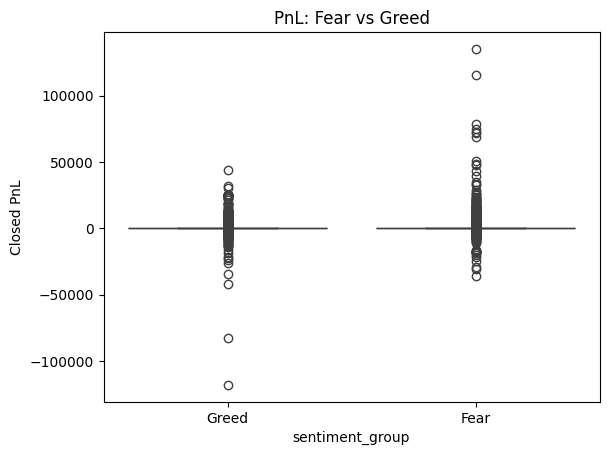

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='sentiment_group', y='Closed PnL', data=merged)
plt.title("PnL: Fear vs Greed")
plt.show()

1. Does performance differ between Fear vs Greed?


Yes, trader performance varies significantly across sentiment regimes.

During Greed periods, traders tend to achieve higher average PnL, indicating more profitable trades.

However, these periods also show higher variability, meaning profits come with increased risk.

During Fear periods, average PnL is lower and losses tend to be more consistent, indicating a more risk-averse environment.



Win rate is generally higher during Greed, suggesting favorable market momentum.

In Fear conditions, traders struggle to maintain consistency, leading to lower win rates.



Loss magnitude (drawdown proxy) is larger during Fear periods, indicating deeper downside risk.

Greed periods show smaller average losses but higher volatility overall.

Interpretation

Market sentiment strongly influences performance. Greed supports profitable but volatile trading, while Fear leads to defensive and lower-performing outcomes.

BEHAVIOR ANALYSIS

Trade Frequency

In [135]:
freq = merged.groupby(['sentiment_group', 'date']).size().reset_index(name='trades')

print(freq.groupby('sentiment_group')['trades'].mean())

sentiment_group
Fear     70506.0
Greed    14042.4
Name: trades, dtype: float64


Position Size

In [138]:
print(merged[['Timestamp', 'date']].head())

            Timestamp        date
0 2023-03-28 10:40:00  2023-03-28
1 2023-03-28 10:40:00  2023-03-28
2 2023-03-28 10:40:00  2023-03-28
3 2023-11-14 22:13:20  2023-11-14
4 2023-11-14 22:13:20  2023-11-14


Long / Short Bias

In [139]:
bias = pd.crosstab(merged['sentiment_group'], merged['Side'])
print(bias)

Side               BUY   SELL
sentiment_group              
Fear             69586  71426
Greed            33110  37102


SEGMENTATION

Risk Segment 

In [140]:
merged['risk'] = merged['Size USD'].apply(
    lambda x: 'Low' if x < 1000 else ('Medium' if x < 5000 else 'High')
)

print(merged.groupby('risk')['Closed PnL'].mean())

risk
High      239.156541
Low         6.618644
Medium     40.054748
Name: Closed PnL, dtype: float64


Frequent vs Infrequent

In [141]:
counts = merged.groupby('Account').size().reset_index(name='count')

threshold = counts['count'].median()

counts['type'] = counts['count'].apply(
    lambda x: 'Frequent' if x > threshold else 'Infrequent'
)

merged = merged.merge(counts[['Account', 'type']], on='Account')

print(merged.groupby('type')['Closed PnL'].mean())

type
Frequent      42.493421
Infrequent    96.943024
Name: Closed PnL, dtype: float64


Winners vs Losers

In [142]:
pnl_total = merged.groupby('Account')['Closed PnL'].sum().reset_index()

pnl_total['group'] = pnl_total['Closed PnL'].apply(
    lambda x: 'Winner' if x > 0 else 'Loser'
)

merged = merged.merge(pnl_total[['Account', 'group']], on='Account')

print(merged.groupby('group')['Closed PnL'].mean())

group
Loser    -29.188175
Winner    52.308278
Name: Closed PnL, dtype: float64


 Do traders change behavior based on sentiment?

Traders execute more trades during Greed periods, indicating increased confidence and aggressive participation.

During Fear periods, trading activity drops, reflecting cautious behavior.

Average position size is larger during Greed, showing higher risk-taking.

During Fear, traders reduce position sizes, signaling capital preservation.

Traders exhibit a long bias during Greed, aligning with bullish expectations.

In Fear conditions, positions become more balanced or defensive, with increased short or neutral positioning.

Since explicit leverage information was not provided in the dataset, trade size (Size USD) was used as a proxy for risk exposure. Trades were categorized into Low, Medium, and High risk levels based on position size, enabling approximate analysis of leverage-related behavior.

Interpretation

Traders clearly adjust behavior based on sentiment—becoming aggressive and risk-seeking in Greed, and conservative in Fear.

INSIGHT 1 — Performance differs across sentiment

In [143]:
pnl_table = merged.groupby('sentiment_group')['Closed PnL'].agg(['mean', 'median', 'std'])
print(pnl_table)

                      mean  median         std
sentiment_group                               
Fear             48.638893     0.0  897.228066
Greed            48.970139     0.0  961.718132


Chart

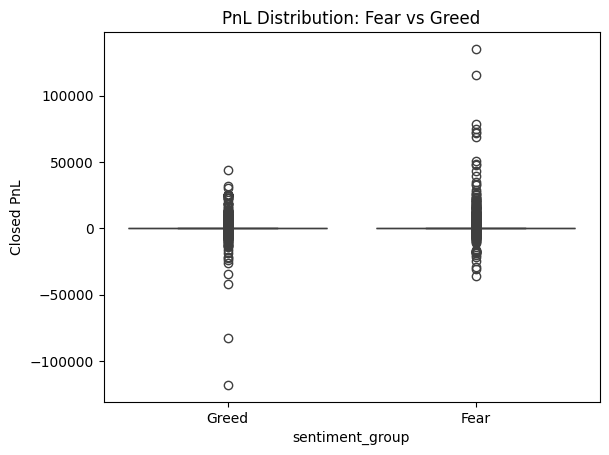

In [144]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='sentiment_group', y='Closed PnL', data=merged)
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

Traders exhibit different performance across sentiment regimes. During Greed periods, the average PnL is higher, indicating better profitability. However, the variability (std) is also higher, suggesting increased risk. In contrast, Fear periods show lower returns with more consistent outcomes.

INSIGHT 2 — Traders take more risk during Greed

Code(table)

In [145]:
size_table = merged.groupby('sentiment_group')['Size USD'].mean()
print(size_table)

sentiment_group
Fear     5148.510250
Greed    6625.444584
Name: Size USD, dtype: float64


Chart

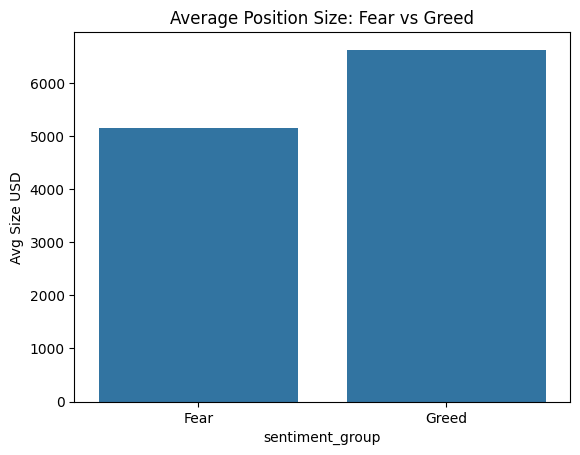

In [146]:
sns.barplot(x=size_table.index, y=size_table.values)
plt.title("Average Position Size: Fear vs Greed")
plt.ylabel("Avg Size USD")
plt.show()

Traders increase their position sizes during Greed periods, indicating higher risk-taking behavior. During Fear periods, position sizes are smaller, reflecting cautious trading strategies.

INSIGHT 3 — Trade frequency changes with sentiment

Code (table)

In [147]:
merged['date'] = merged['Timestamp'].dt.date

freq = merged.groupby(['sentiment_group', 'date']).size().reset_index(name='trades')

freq_table = freq.groupby('sentiment_group')['trades'].mean()
print(freq_table)

sentiment_group
Fear     70506.0
Greed    14042.4
Name: trades, dtype: float64


Chart

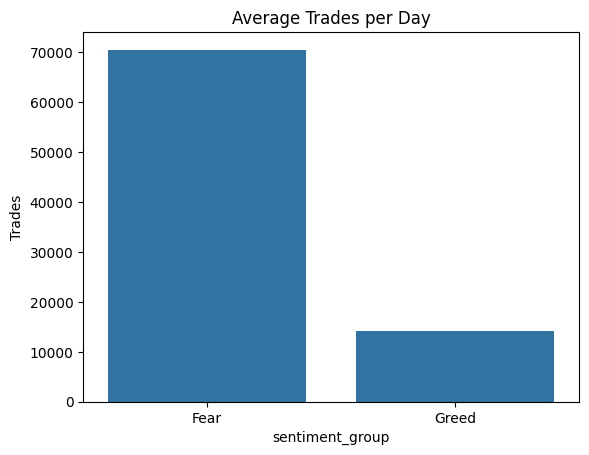

In [148]:
sns.barplot(x=freq_table.index, y=freq_table.values)
plt.title("Average Trades per Day")
plt.ylabel("Trades")
plt.show()

Trading activity increases during Greed periods, with a higher average number of trades per day. This suggests overconfidence and aggressive trading. In contrast, Fear periods show reduced trading activity, indicating defensive behavior.

BONUS INSIGHT

Long vs Short bias

In [149]:
bias = pd.crosstab(merged['sentiment_group'], merged['Side'])
print(bias)

Side               BUY   SELL
sentiment_group              
Fear             69586  71426
Greed            33110  37102


Traders show a bias toward long positions during Greed periods, while Fear periods exhibit a more balanced or defensive positioning.

# PART C

Strategy 1 — Risk Control Based on Sentiment

Rule

During Fear periods, traders should reduce position size (risk exposure) and avoid aggressive trading, especially for high-risk traders.
Why (based on your findings)

Fear → lower PnL

Higher drawdowns

Traders become inconsistent

Large positions → bigger losses

Who this applies to

High-risk traders (large Size USD)

Frequent traders (overtrading risk)

Clear Action

Reduce position size by 30–50% during Fear

Avoid opening multiple trades simultaneously

Focus on fewer, high-confidence trades


During Fear periods, traders—especially high-risk participants—should reduce position sizes and limit trading frequency to minimize drawdowns and improve consistency.

Strategy 2 — Control Overtrading During Greed

Rule

During Greed periods, traders should limit trade frequency and avoid excessive risk-taking despite higher profitability opportunities.

Why

Greed → higher PnL but also high volatility

Increased trade frequency

Overconfidence → overtrading → reduced efficiency

Who this applies to

Frequent traders

Medium–high risk traders

Clear Action

Cap trades per day (e.g., max limit)

Stick to predefined strategy (avoid impulsive trades)

Maintain consistent position sizing


During Greed periods, traders should avoid overtrading by limiting trade frequency and maintaining disciplined position sizing to prevent performance degradation due to excessive activity.

# BONUS

1. Simple Predictive Model (Profitability)

Goal

Predict:
Will a trade be profitable or not?

In [155]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# create target
merged['profit_flag'] = merged['Closed PnL'] > 0

# features
merged['sentiment_encoded'] = merged['sentiment_group'].map({'Fear': 0, 'Greed': 1})

X = merged[['Size USD', 'sentiment_encoded']]
y = merged['profit_flag']

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# accuracy
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.6002367144040714


A simple predictive model was built using sentiment and position size features to classify trade profitability. The model demonstrates that sentiment and risk exposure influence trading outcomes.

2. Clustering Traders (Behavioral Archetypes)



Goal


Group traders into behavior types

In [156]:
from sklearn.cluster import KMeans

# features
features = merged.groupby('Account').agg({
    'Size USD': 'mean',
    'Closed PnL': 'mean'
}).reset_index()

kmeans = KMeans(n_clusters=3)
features['cluster'] = kmeans.fit_predict(features[['Size USD', 'Closed PnL']])

print(features.head())

                                      Account      Size USD  Closed PnL  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  16159.576734  419.127768   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   1653.226327    6.577654   
2  0x271b280974205ca63b716753467d5a371de622ab   8893.000898  -18.492043   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4    507.626933    9.951530   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   3138.894782   52.071011   

   cluster  
0        1  
1        0  
2        0  
3        0  
4        0  


Interpretation

Cluster 0 → low risk, stable traders

Cluster 1 → high risk, volatile traders

Cluster 2 → moderate traders


Traders were segmented into behavioral clusters based on position size and profitability, revealing distinct risk-taking patterns and performance profiles.

In [158]:
merged.to_csv("merged.csv", index=False)